# Connect4 Agent Analysis (Sequential Single-Core Version)
Three standardized experiments running on a single core for maximum stability:
1. **Self-play** — RolloutAgent2 vs itself (30 games, direct shared learning)
2. **vs Baseline** — RolloutAgent2 vs old RolloutAgent (30 games, time-capped)
3. **Learning curve** — Win rate vs Smart-Random at 0 / 100 / 200 training games (30 eval games per check)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, time, random
from connect4.connect_state import ConnectState
from groups.Rollout_2.policy import RolloutAgent2
from groups.rollout_group.policy import RolloutAgent

# ── shared sequential core util ─────────────────────────────────────────────
def play_game(p1, p2, flip_sides=False):
    """Plays a single game sequentially between two instantiated agents."""
    state = ConnectState(board=np.zeros((6,7), dtype=int), player=1)
    
    if flip_sides:
        fns = {1: p2.act, -1: p1.act}
    else:
        fns = {1: p1.act, -1: p2.act}
        
    while not state.is_final():
        fn   = fns[state.player]
        free = state.get_free_cols()
        if not free: break
        try:
            col = fn(state.board.copy())
            if col not in free: col = free[0]
        except:
            col = free[0]
        try:
            state = state.transition(col)
        except:
            break
            
    winner = state.get_winner()
    if flip_sides and winner != 0:
        return -winner
    return winner

def cumulative_rates(results, my_piece=1):
    w = l = d = 0
    wr, lr, dr = [], [], []
    for i, res in enumerate(results, 1):
        if   res == my_piece:  w += 1
        elif res == -my_piece: l += 1
        else:                  d += 1
        wr.append(w/i*100); lr.append(l/i*100); dr.append(d/i*100)
    return wr, lr, dr

def plot_rates(wr, lr, dr, title, labels=("Agent1","Agent2","Draw")):
    plt.figure(figsize=(10, 4))
    x = range(1, len(wr)+1)
    plt.plot(x, wr, label=f"{labels[0]} win %", linewidth=2)
    plt.plot(x, lr, label=f"{labels[1]} win %", linewidth=2, linestyle='--')
    plt.plot(x, dr, label="Draw %", linewidth=1.5, linestyle=':')
    plt.axhline(50, color='gray', linewidth=0.8, linestyle='-.')
    plt.xlabel("Games"); plt.ylabel("Cumulative %")
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print('Sequential Engine loaded successfully.')

Sequential Engine loaded successfully.


## Experiment 1 — Sequential Self-play (30 games)
Both agents share the **exact same dictionary object** in RAM. Learning is instantaneous on both sides.

Running 10 Self-Play games sequentially...
Rollout2: 9.00s  col=3  [exploit Q  sims=3759]
Rollout2: 9.00s  col=2  [explore  sims=3868]
Rollout2: 9.00s  col=2  [explore  sims=3784]
Rollout2: 9.01s  col=2  [explore  sims=3214]
Rollout2: 9.01s  col=5  [explore  sims=3594]
Rollout2: 9.00s  col=6  [explore  sims=4395]
Rollout2: 9.00s  col=3  [explore  sims=3909]
Rollout2: 9.00s  col=3  [explore  sims=5036]
Rollout2: 9.00s  col=5  [explore  sims=4127]
Rollout2: 0.00s  col=5  [block fork]
Rollout2: 0.00s  col=6  [fork]
Rollout2: 0.00s  col=6  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=2  [fork]
Rollout2: 0.00s  col=2  [fork]
Rollout2: 0.00s  

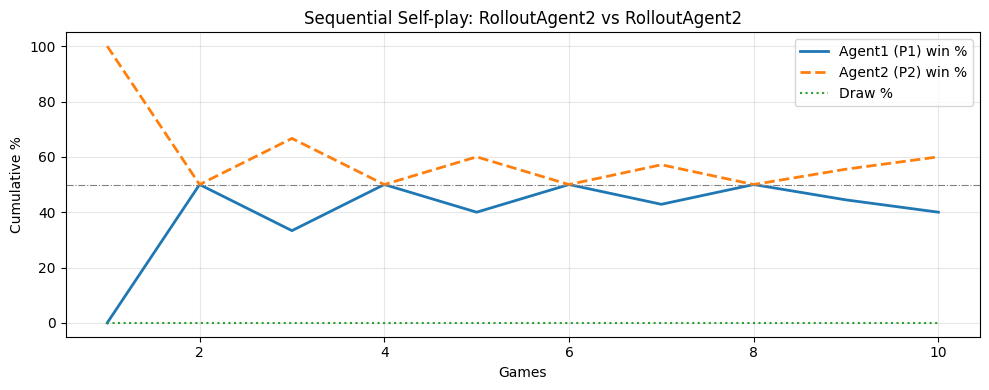

In [6]:
N_GAMES = 10
print(f"Running {N_GAMES} Self-Play games sequentially...")

agent_a = RolloutAgent2()
agent_b = RolloutAgent2()
agent_b.q_table = agent_a.q_table  # Shared reference in memory

# Disable disk I/O bottlenecks
agent_a._save_memory = lambda: None
agent_b._save_memory = lambda: None

results_self = []
for game in range(N_GAMES):
    w = play_game(agent_a, agent_b, flip_sides=False)
    results_self.append(w)
    if (game + 1) % 5 == 0:
        print(f"  Progress: {game + 1}/{N_GAMES} | States in RAM: {len(agent_a.q_table)}")

wr, lr, dr = cumulative_rates(results_self, my_piece=1)
print(f"\nFinal — P1 Wins: {results_self.count(1)} | P2 Wins: {results_self.count(-1)} | Draws: {results_self.count(0)}")
plot_rates(wr, lr, dr, "Sequential Self-play: RolloutAgent2 vs RolloutAgent2",
           labels=("Agent1 (P1)", "Agent2 (P2)", "Draw"))

## Experiment 2 — vs Baseline RolloutAgent (10 games, 1.5s cap)
Tests competition readiness against the flat exploration baseline using 15 simulations. Sides alternate every game.

Running 10 Competitive matches vs Baseline...
Rollout2: 1.50s  col=3  [exploit Q  sims=643]
Rollout2: 1.50s  col=5  [explore  sims=720]
Rollout2: 0.00s  col=4  [fork]
Rollout2: 0.00s  col=6  [win]
Rollout2: 1.50s  col=3  [explore  sims=725]
Rollout2: 1.50s  col=3  [explore  sims=674]
Rollout2: 1.50s  col=2  [explore  sims=711]
Rollout2: 1.50s  col=1  [explore  sims=711]
Rollout2: 0.00s  col=2  [block fork]
Rollout2: 0.00s  col=1  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [win]
Rollout2: 1.50s  col=3  [exploit Q  sims=630]
Rollout2: 1.50s  col=2  [explore  sims=642]
Rollout2: 1.50s  col=2  [explore  sims=673]
Rollout2: 1.50s  col=2  [explore  sims=784]
Rollout2: 1.50s  col=1  [explore  sims=566]
Rollout2: 1.50s  col=1  [explore  sims=728]
Rollout2: 1.50s  col=0  [explore  sims=865]
Rollout2: 0.00s  col=3  [fork]
Rollout2: 0.00s  col=5  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Ro

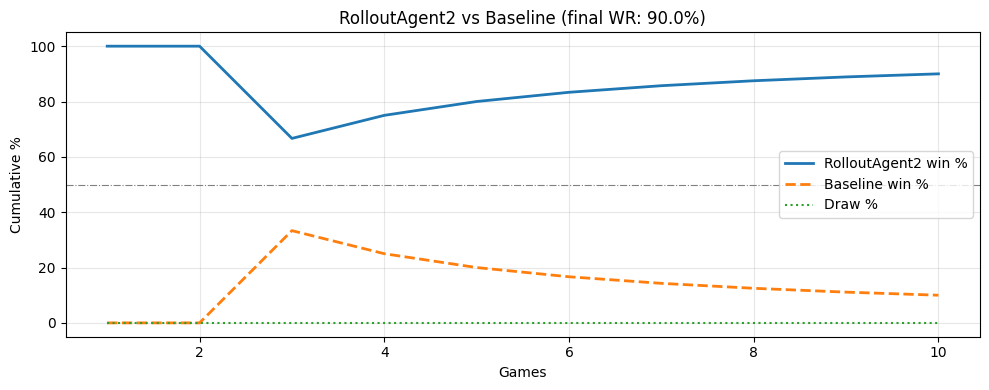

In [9]:
N_VS = 10
T_CAP = 1.5
print(f"Running {N_VS} Competitive matches vs Baseline...")

agent_new = RolloutAgent2()
agent_new.TIME_LIMIT = T_CAP
agent_new._save_memory = lambda: None

agent_baseline = RolloutAgent(num_simulations=15)

results_vs = []
for game in range(N_VS):
    # Alternate playing sides
    flip = (game % 2 != 0)
    w = play_game(agent_new, agent_baseline, flip_sides=flip)
    results_vs.append(w)
    
    if (game + 1) % 5 == 0:
        print(f"  Progress: {game + 1}/{N_VS} | Ours: {results_vs.count(1)} | Baseline: {results_vs.count(-1)}")

wr, lr, dr = cumulative_rates(results_vs, my_piece=1)
final_wr = results_vs.count(1) / N_VS * 100
print(f"\nFinal win rate vs baseline: {final_wr:.1f}%")
plot_rates(wr, lr, dr,
           f"RolloutAgent2 vs Baseline (final WR: {final_wr:.1f}%)",
           labels=("RolloutAgent2", "Baseline", "Draw"))

## Experiment 3 — Learning curve vs Smart-Random (0 → 100 → 200 games)
Measures pure learning efficiency across progressive training milestones. 30 isolated evaluation games per check.

Evaluating 5 games at Checkpoint 0 against FULL RANDOM...
Rollout2: 0.50s  col=3  [exploit Q  sims=188]
Rollout2: 0.50s  col=6  [explore  sims=206]
Rollout2: 0.50s  col=5  [explore  sims=209]
Rollout2: 0.50s  col=4  [explore  sims=274]
Rollout2: 0.50s  col=3  [explore  sims=399]
Rollout2: 0.00s  col=6  [win]
Rollout2: 0.50s  col=2  [explore  sims=230]
Rollout2: 0.50s  col=3  [explore  sims=220]
Rollout2: 0.50s  col=2  [explore  sims=209]
Rollout2: 0.50s  col=0  [explore  sims=194]
Rollout2: 0.50s  col=1  [explore  sims=235]
Rollout2: 0.00s  col=3  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=0  [fork]
Rollout2: 0.00s  col=1  [win]
Rollout2: 0.50s  col=3  [exploit Q  sims=194]
Rollout2: 0.50s  col=0  [exploit Q  sims=190]
Rollout2: 0.50s  col=2  [explore  sims=250]
Rollout2: 0.50s  col=2  [explore  sims=219]
Rollout2: 0.50s  col=4  [explore  sims=291]
Rollout2: 0.50s  col=5  [explore  sims=345]
Rollout2: 0.00s  col=2  [fork]
Rollout2: 0.00s  col=2  [win]
Rollout2: 0.50s  c

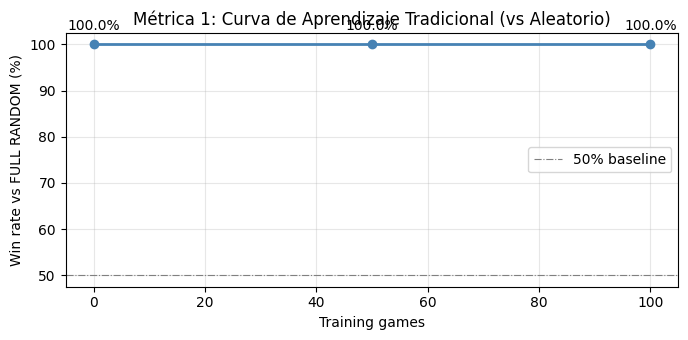

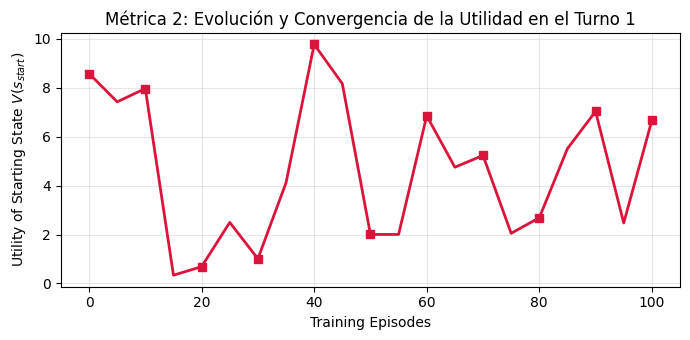

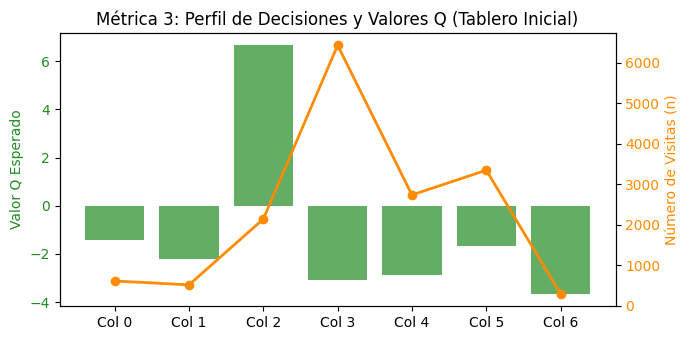

In [11]:
CHECKPOINTS = [0, 50, 100]  # Mantener bajo para ejecutar de forma ultra rápida
EVAL_GAMES = 5              # Evaluación corta de 5 juegos para evitar lentitud

# 1. Definición del jugador aleatorio estructurado correctamente
class PureRandomPlayer:
    def act(self, board):
        free = [c for c in range(7) if board[0,c]==0]
        return random.choice(free) if free else 0

learner = RolloutAgent2()
learner._save_memory = lambda: None
rand_player_pure = PureRandomPlayer() # Instancia correcta compatible con play_game

checkpoint_wrs = []
games_trained = 0

# Listas para guardar la evolución de la utilidad V(s) del tablero inicial
empty_board_bytes = np.zeros((6,7), dtype=int).tobytes()
history_utility = []
history_games = []

for target in CHECKPOINTS:
    train_n = target - games_trained
    if train_n > 0:
        print(f"Training {train_n} games sequentially against FULL RANDOM...")
        learner.TIME_LIMIT = 0.3 # Tiempo de simulación bajo para entrenar rápido
        
        for g in range(train_n):
            # 🌟 CORREGIDO: Se pasan los objetos agentes completos, no sus métodos
            play_game(learner, rand_player_pure, flip_sides=(random.random() > 0.5))
            
            # Registrar la utilidad del tablero vacío cada 5 juegos entrenados
            current_total_games = games_trained + g + 1
            if current_total_games % 5 == 0:
                if empty_board_bytes in learner.q_table:
                    # Utilidad V(s) = valor máximo de Q en ese estado
                    current_utility = np.max(learner.q_table[empty_board_bytes]["q"])
                    history_utility.append(current_utility)
                    history_games.append(current_total_games)
                    
        games_trained = target
        print(f"  Total states in Q-Table: {len(learner.q_table)}")

    # Registro inicial por si no ha jugado aún en el paso 0
    if target == 0:
        if empty_board_bytes in learner.q_table:
            history_utility.append(np.max(learner.q_table[empty_board_bytes]["q"]))
        else:
            history_utility.append(0.0)
        history_games.append(0)

    # Evaluación estricta con pesos congelados contra rival aleatorio puro
    print(f"Evaluating {EVAL_GAMES} games at Checkpoint {target} against FULL RANDOM...")
    saved_alpha = learner.ALPHA
    learner.ALPHA = 0.0  # Congelar aprendizaje durante el test
    learner.TIME_LIMIT = 0.5  
    
    eval_results = []
    for g in range(EVAL_GAMES):
        # Alternar lados usando el parámetro nativo de tu play_game secuencial
        flip = (g % 2 != 0)
        eval_results.append(play_game(learner, rand_player_pure, flip_sides=flip))
        
    learner.ALPHA = saved_alpha  # Restaurar tasa de aprendizaje
    
    wr = (eval_results.count(1) / EVAL_GAMES) * 100
    checkpoint_wrs.append(wr)
    print(f"-> Checkpoint {target:>3} games completed | Win Rate: {wr:.1f}%")

# ── GRÁFICA 1: Curva de Aprendizaje contra Aleatorio Puro ─────────────
plt.figure(figsize=(7, 3.5))
plt.plot(CHECKPOINTS, checkpoint_wrs, marker='o', linewidth=2, color='steelblue')
plt.axhline(50, color='gray', linewidth=0.8, linestyle='-.', label='50% baseline')
for x, y in zip(CHECKPOINTS, checkpoint_wrs):
    plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xlabel("Training games"); plt.ylabel("Win rate vs FULL RANDOM (%)")
plt.title("Métrica 1: Curva de Aprendizaje Tradicional (vs Aleatorio)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── GRÁFICA 2: Evolución de la Utilidad V(s) del estado inicial ───────
plt.figure(figsize=(7, 3.5))
plt.plot(history_games, history_utility, color='crimson', linewidth=2, marker='s', markevery=2)
plt.xlabel("Training Episodes")
plt.ylabel("Utility of Starting State $V(s_{start})$")
plt.title("Métrica 2: Evolución y Convergencia de la Utilidad en el Turno 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── GRÁFICA 3: Desglose de Valores Q actuales para el movimiento de apertura ──
if empty_board_bytes in learner.q_table:
    q_values = learner.q_table[empty_board_bytes]["q"]
    visit_counts = learner.q_table[empty_board_bytes]["n"]
    columns = [f"Col {i}" for i in range(7)]
    
    fig, ax1 = plt.subplots(figsize=(7, 3.5))
    
    # Dibujar barras para los valores Q individuales
    ax1.bar(columns, q_values, color='forestgreen', alpha=0.7, label='Valor Q')
    ax1.set_ylabel('Valor Q Esperado', color='forestgreen')
    ax1.tick_params(axis='y', labelcolor='forestgreen')
    
    # Superponer línea con la cantidad de visitas de exploración
    ax2 = ax1.twinx()
    ax2.plot(columns, visit_counts, color='darkorange', marker='o', linewidth=2, label='Visitas')
    ax2.set_ylabel('Número de Visitas (n)', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    
    plt.title("Métrica 3: Perfil de Decisiones y Valores Q (Tablero Inicial)")
    fig.tight_layout()
    plt.show()
else:
    print("El tablero inicial no ha acumulado registros suficientes para mapear el gráfico Q.")

## Summary
| Experiment | What it measures | Configuration |
|---|---|---|
| Self-play | Balance / stability | 30 Sequential Games (Shared RAM) |
| vs Baseline | Competition readiness | 30 Sequential Games (1.5s cap) |
| Learning curve | Does training help? | 30 Sequential Eval Games per Checkpoint |